# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [4]:
cols_with_nan = df.columns[df.isnull().any()]

cols_with_nan = [
    col for col in cols_with_nan
    if df[col].isnull().sum() < len(df)
]

for col in cols_with_nan:
    print(col)
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print()

SepalLengthCm
Median: 6.3
Std: 1.0371145018646923

SepalWidthCm
Median: 2.9
Std: 0.38956399923008017

PetalLengthCm
Median: 5.085611510791367
Std: 1.5828073840563788

PetalWidthCm
Median: 1.6
Std: 0.706689351902183

BranchLength
Median: 16.3
Std: 1.0352277983261677



In [5]:
from sklearn.impute import KNNImputer

df_numeric = df.select_dtypes(include=[np.number])

df_numeric = df_numeric.drop(columns=[
    col for col in df_numeric.columns if df_numeric[col].isnull().sum() == len(df_numeric)
])

# KNN Imputer
imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_numeric),
    columns=df_numeric.columns
)

for col in df_imputed.columns:
    if col in cols_with_nan:
        print(col)
        print("Median:", df_imputed[col].median())
        print("Std:", df_imputed[col].std())
        print()

SepalLengthCm
Median: 6.3
Std: 1.0122885669044033

SepalWidthCm
Median: 2.8899999999999997
Std: 0.37114996725904853

PetalLengthCm
Median: 5.078561151079136
Std: 1.3655986872212327

PetalWidthCm
Median: 1.65
Std: 0.6935586186581708

BranchLength
Median: 16.3
Std: 1.0139036994821784



## Data Preprocessing

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------

    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,472.000000,443.000000,350.000000,478.000000,476.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.320551,2.837472,5.085612,1.675732,16.302941,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.037115,0.389564,1.582807,0.706689,1.035228,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.600000,4.425000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.085612,1.600000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.100000,5.500000,2.000000,16.800000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

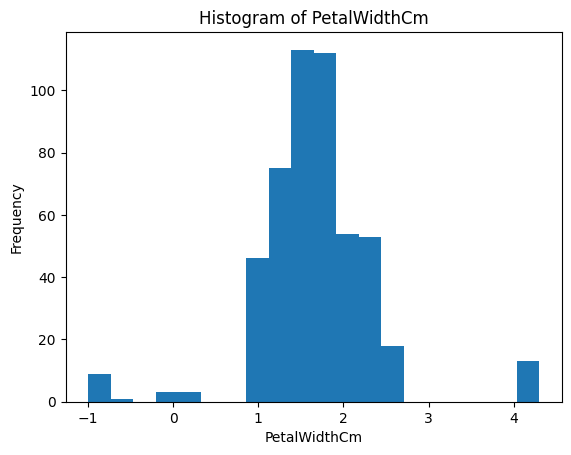

In [8]:
import matplotlib.pyplot as plt

plt.hist(df_imputed['PetalWidthCm'], bins=20)
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.show()

In [9]:
from sklearn.feature_selection import r_regression
import numpy as np

#Zielvariable
y = df_imputed['PetalWidthCm']

#Features ohne die ausgeschlossenen Spalten
X = df_imputed.drop(columns=['PetalWidthCm', 'Species', 'Id'], errors='ignore')

#Pearson correlations
corr = r_regression(X, y)

# Bestes Feature finden
best_idx = np.argmax(corr)
best_feature = X.columns[best_idx]
best_value = corr[best_idx]

print(best_feature, best_value)

PetalWidthCompactness 0.9932236056586443


In [10]:
#negative correlations sortieren
sorted_idx = np.argsort(corr)  # aufsteigend

#Top 5 negative
neg_idx = sorted_idx[:5]

for i in neg_idx:
    print(X.columns[i], corr[i])

SepalWidthMajorAxis -0.09383698069582481
SepalGlossIndex -0.09294380019512077
SepalWidthCompactness -0.08435946396017115
SepalWidthCurvature -0.07988601498914033
SepalWidthMinorAxis -0.07244700769347985


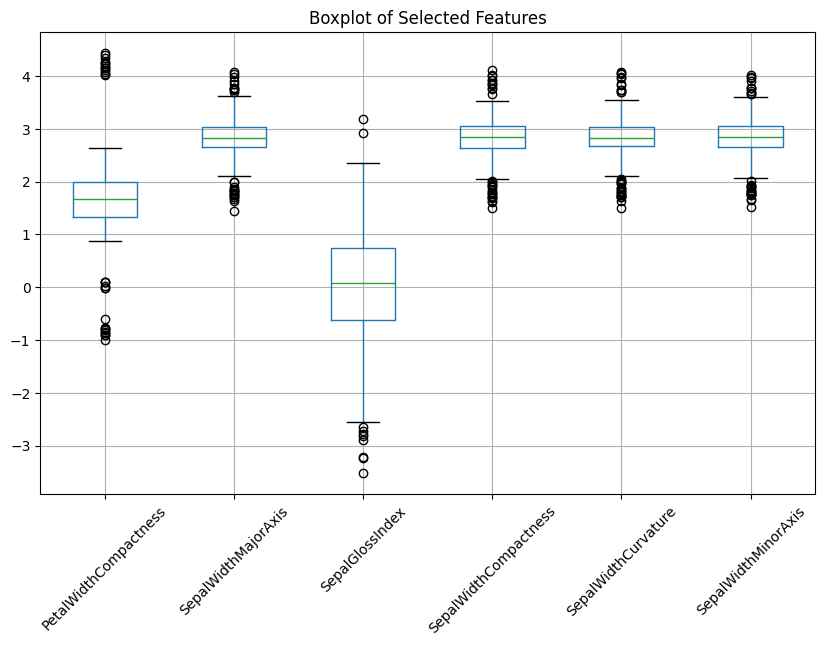

In [11]:
import matplotlib.pyplot as plt

features = [
    'PetalWidthCompactness',
    'SepalWidthMajorAxis',
    'SepalGlossIndex',
    'SepalWidthCompactness',
    'SepalWidthCurvature',
    'SepalWidthMinorAxis'
]

plt.figure(figsize=(10,6))
df_imputed[features].boxplot()
plt.title('Boxplot of Selected Features')
plt.xticks(rotation=45)
plt.show()

In [12]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

## Model Training

### Prepare the data

In [15]:
from sklearn.model_selection import train_test_split

# Features aus dem imputierten numerischen DataFrame
X = df_imputed[feature_cols].values.astype(float)

# Target aus dem ursprünglichen DataFrame
y = df['Species'].values

# Falls Species Strings sind und du eine binäre Klassifikation brauchst:
classes = sorted(pd.Series(y).unique())
print("Classes:", classes)

y = (pd.Series(y) == classes[1]).astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

Classes: [np.int64(0), np.int64(1)]


In [14]:
print(pd.Series(y).unique())

[ 1.4   1.5   1.3   4.1   0.    1.    1.46  1.1   1.8   1.2   1.7   1.82
  1.6  -0.8   1.9   2.5   2.1   2.    2.4   2.3   2.2   1.98 -0.9  -0.6
  2.6   0.9   4.2   1.78  1.32  0.96  0.1   1.42  1.46  4.3   1.84  1.86
  2.08  1.36  1.42  1.76 -1.  ]


### Train the model!

50. Training loss: nan, Val loss: nan
100. Training loss: nan, Val loss: nan
150. Training loss: nan, Val loss: nan
200. Training loss: nan, Val loss: nan
250. Training loss: nan, Val loss: nan
300. Training loss: nan, Val loss: nan
350. Training loss: nan, Val loss: nan
400. Training loss: nan, Val loss: nan
450. Training loss: nan, Val loss: nan
500. Training loss: nan, Val loss: nan
550. Training loss: nan, Val loss: nan
600. Training loss: nan, Val loss: nan
650. Training loss: nan, Val loss: nan
700. Training loss: nan, Val loss: nan
750. Training loss: nan, Val loss: nan
800. Training loss: nan, Val loss: nan
850. Training loss: nan, Val loss: nan
900. Training loss: nan, Val loss: nan
950. Training loss: nan, Val loss: nan
1000. Training loss: nan, Val loss: nan
1050. Training loss: nan, Val loss: nan
1100. Training loss: nan, Val loss: nan
1150. Training loss: nan, Val loss: nan
1200. Training loss: nan, Val loss: nan
1250. Training loss: nan, Val loss: nan
1300. Training loss:

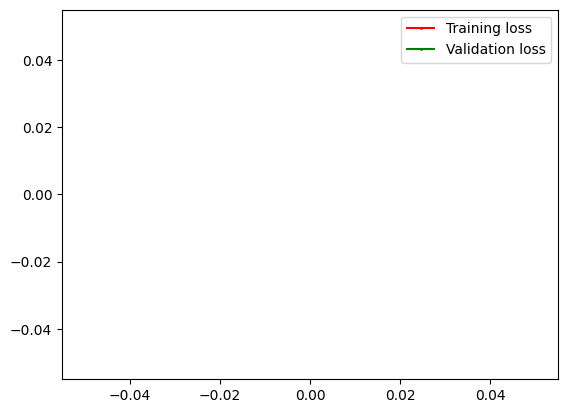

Model parameters (weights): [[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]
Sum of absolute values of weights: nan


In [ ]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='l2', reg_lambda=0.01)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.4933
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000


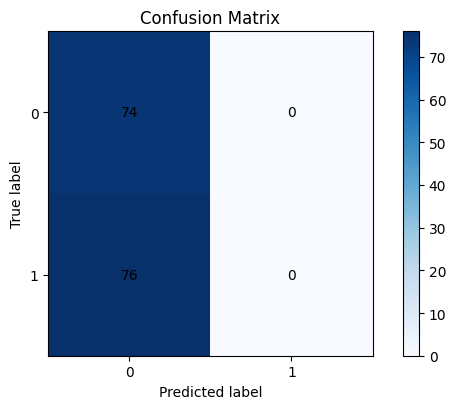

{'Accuracy': 0.49333333333333335,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-score': 0.0}

In [ ]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)